<a href="https://colab.research.google.com/github/nblandinamerry-1/N.-Blandina-Merry/blob/main/Brain_signal_analysis_for_motor_imagery_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Install Necessary Libraries

First, we need to install the `mne` library, which is essential for reading and processing EEG data. We will also install `tensorflow` for building the neural network model, if it's not already present.

In [ ]:
pip install mne tensorflow

## Step 2: Upload and Unzip the EEG Data

We'll upload the zipped GDF file containing the EEG data and then extract its contents. The GDF file stores the raw EEG signals.

In [ ]:
from google.colab import files
import zipfile
import os

print("Please upload the BCICIV_2a_gdf.zip file.")
uploaded = files.upload()

zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.')

# Find the GDF file inside the unzipped folder. Assuming 'A02T.gdf' for this example.
unzipped_files = os.listdir('.')
gdf_file_name = [f for f in unzipped_files if f.endswith('.gdf')][0]
print(f"Extracted GDF file: {gdf_file_name}")

Please upload the BCICIV_2a_gdf.zip file.


MessageError: TypeError: can't access property "next", steps is undefined

## Step 3: Load and Preprocess Raw EEG Data with MNE

We'll use MNE to read the GDF file, load the data into memory, and then apply a band-pass filter to isolate the motor imagery frequency band (7-30 Hz).

In [ ]:
import mne

raw = mne.io.read_raw_gdf(gdf_file_name, preload=True)
raw.filter(7., 30.)  # Motor imagery band
print(raw.info)

## Step 4: Extract Events and Create Epochs

Events (markers indicating specific actions or stimuli) are extracted from the raw data. Then, `epochs` are created by segmenting the continuous raw data around these events. We specify `event_repeated='merge'` to handle multiple events at the same time point and `baseline=(0, 0)` for baseline correction.

In [ ]:
events, event_id = mne.events_from_annotations(raw)
print("Event IDs found:", event_id)

# Create epochs around the events of interest.
# tmin and tmax define the time window around each event.
# preload=True loads all data into RAM.
# event_repeated='merge' handles cases where multiple events occur at the same sample.
# baseline=(0, 0) applies no baseline correction or a baseline from time 0 to 0 (effectively no pre-event baseline).
epochs = mne.Epochs(raw, events, event_id, tmin=0, tmax=2, preload=True, event_repeated='merge', baseline=(0, 0))

# Get the epoched data and corresponding labels.
data = epochs.get_data() # data shape: (n_epochs, n_channels, n_times)
labels = epochs.events[:, -1] # Extract event IDs as labels

## Step 5: Feature Extraction

For each epoch and each channel, we extract several time-domain and a basic frequency-domain feature (mean absolute FFT). These features will serve as input for our machine learning model.

In [ ]:
import numpy as np
import pandas as pd

features = []

for trial in data: # trial shape: (n_channels, n_times)
    epoch_features = []
    n_channels = trial.shape[0]

    for channel_idx in range(n_channels):
        channel_data = trial[channel_idx, :] # channel_data shape: (n_times,)

        # Mean
        epoch_features.append(np.mean(channel_data))

        # Variance
        epoch_features.append(np.var(channel_data))

        # RMS (Root Mean Square)
        epoch_features.append(np.sqrt(np.mean(channel_data**2)))

        # Max amplitude
        epoch_features.append(np.max(channel_data))

        # Min amplitude
        epoch_features.append(np.min(channel_data))

        # Frequency (approx using Mean of Absolute FFT components)
        # Note: A more sophisticated frequency feature would involve power spectral density.
        fft_channel = np.fft.fft(channel_data)
        freq_feature = np.mean(np.abs(fft_channel)) # Simple average of magnitudes
        epoch_features.append(freq_feature)
    features.append(epoch_features)

# Create column names for the new DataFrame
n_features_per_channel = 6
feature_names = ["Mean", "Variance", "RMS", "Max", "Min", "Frequency"]
all_column_names = []
for ch_idx in range(n_channels):
    for f_name in feature_names:
        all_column_names.append(f"{f_name}_ch{ch_idx+1}")

df = pd.DataFrame(features, columns=all_column_names)
df["Label"] = labels

print("Features DataFrame head:")
display(df.head())

## Step 6: Prepare Data for Machine Learning

This step involves several crucial substeps:
1.  **Separating Features (X) and Labels (y)**: `X` will contain the extracted features, and `y` will contain the corresponding event labels.
2.  **Label Mapping**: The raw event IDs (e.g., 769, 770) are mapped to simpler, binary labels (0 and 1) for classification.
3.  **Filtering**: Only epochs corresponding to the two motor imagery classes (left hand and right hand) are kept.
4.  **Handling Missing/Infinite Values**: Ensures the data is clean for the model.
5.  **Scaling Features**: `StandardScaler` is used to normalize feature values, which is important for many machine learning models, especially neural networks.
6.  **Train-Test Split**: The data is divided into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Re-extract X and y from the original DataFrame `df`
X = df.drop("Label", axis=1)
y = df["Label"]

# Ensure X and y are numpy arrays for consistent processing
X = np.array(X)
y = np.array(y)

# Convert labels:
# Based on the event_id from MNE, '769' (Motor imagery: left hand) corresponds to label 7,
# and '770' (Motor imagery: right hand) corresponds to label 8.
# We will map these to 0 and 1 respectively for binary classification.
y_mapped = np.where(y == event_id[np.str_('769')], 0, y) # Map '769' to 0
y_mapped = np.where(y_mapped == event_id[np.str_('770')], 1, y_mapped) # Map '770' to 1

# Keep only the two classes (0 and 1) after conversion
# This ensures we only analyze left and right hand motor imagery.
mask = (y_mapped == 0) | (y_mapped == 1)
X = X[mask]
y = y_mapped[mask] # Use the mapped labels here

# Clean NaN / inf values in X (important for models)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Final check of data shape and unique labels
print(f"Shape of X after filtering: {X.shape}")
print(f"Shape of y after filtering: {y.shape}")
print(f"Unique labels after mapping and filtering: {np.unique(y)}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.05, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

## Step 7: Build and Train a Neural Network Model

We'll define a simple feedforward neural network using Keras (TensorFlow backend) with a few dense layers. The model is compiled with an Adam optimizer and `binary_crossentropy` loss, suitable for binary classification. Then, it's trained on the `X_train` and `y_train` data.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    # Input layer with 16 neurons, 'relu' activation, and input shape matching the number of features
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    # Hidden layer with 8 neurons and 'relu' activation
    Dense(8, activation='relu'),
    # Output layer with 1 neuron and 'sigmoid' activation for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Training the model...")
# Train the model for 50 epochs (iterations over the entire dataset)
model.fit(X_train, y_train, epochs=50, verbose=1)

print("Model training complete.")

## Step 8: Evaluate the Model

After training, we evaluate the model's performance on the unseen test data (`X_test` and `y_test`) to determine its accuracy and loss.

In [ ]:
print("Evaluating the model...")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

## Step 9: Visualize Data Separability with PCA

Principal Component Analysis (PCA) is used to reduce the dimensionality of our features to 2 components, allowing us to visualize how well the 'Left Hand Imagery' and 'Right Hand Imagery' classes are separated in the feature space. A clear separation in this plot would indicate that our extracted features are discriminative.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions for visualization on the scaled data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) # Use X_scaled for PCA

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data = X_pca, columns = ['principal component 1', 'principal component 2'])
pca_df['label'] = y # Use the mapped labels

# Map numerical labels to descriptive strings for better plotting
pca_df['movement_type'] = pca_df['label'].map({0: 'Left Hand Imagery', 1: 'Right Hand Imagery'})

# Plot the principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='movement_type', data=pca_df, s=60, palette='viridis')
plt.title('2-Component PCA of EEG Features for Motor Imagery')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()

## Step 10: Download the Extracted Features (Optional)

You can download the extracted features and labels to an Excel file for further analysis or archiving.

In [ ]:
df.to_excel("EEG_BCI_Dataset.xlsx", index=False)
files.download("EEG_BCI_Dataset.xlsx")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BCICIV_2a_gdf.zip to BCICIV_2a_gdf.zip


In [ ]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [ ]:
# Unzip the uploaded file
import zipfile
import os

zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.')

# Find the GDF file inside the unzipped folder
unzipped_files = os.listdir('.')
gdf_file_name = [f for f in unzipped_files if f.endswith('.gdf')][0]
print(f"Extracted GDF file: {gdf_file_name}")

Extracted GDF file: A02T.gdf


In [ ]:
import mne

raw = mne.io.read_raw_gdf(gdf_file_name, preload=True)
raw.filter(7., 30.)  # Motor imagery band
print(raw.info)

Extracting GDF parameters from A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 677168  =      0.000 ...  2708.672 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 7.0 Hz
 lowpass: 30.0 Hz
 meas_date: 2004-11-15 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A02, sex: 0, last_name: X, birthday: 1980-11-15>
>


In [ ]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}


In [ ]:
epochs = mne.Epochs(raw, events, event_id, tmin=0, tmax=2, preload=True, event_repeated='merge', baseline=(0, 0))
data = epochs.get_data()
labels = epochs.events[:, -1]

Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
585 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 585 events and 501 original time points ...
0 bad epochs dropped


In [ ]:
import numpy as np
import pandas as pd

features = []

for trial in data: # trial shape: (n_channels, n_times)
    epoch_features = []
    n_channels = trial.shape[0]

    for channel_idx in range(n_channels):
        channel_data = trial[channel_idx, :] # channel_data shape: (n_times,)

        # Mean
        epoch_features.append(np.mean(channel_data))

        # Variance
        epoch_features.append(np.var(channel_data))

        # RMS
        epoch_features.append(np.sqrt(np.mean(channel_data**2)))

        # Max amplitude
        epoch_features.append(np.max(channel_data))

        # Min amplitude
        epoch_features.append(np.min(channel_data))

        # Frequency (approx using FFT)
        fft_channel = np.fft.fft(channel_data)
        freq_channel = np.mean(np.abs(fft_channel))
        epoch_features.append(freq_channel)
    features.append(epoch_features)

# Create column names for the new DataFrame
n_features_per_channel = 6
feature_names = ["Mean", "Variance", "RMS", "Max", "Min", "Frequency"]
all_column_names = []
for ch_idx in range(n_channels):
    for f_name in feature_names:
        all_column_names.append(f"{f_name}_ch{ch_idx+1}")

df = pd.DataFrame(features, columns=all_column_names)
df["Label"] = labels

In [ ]:
df.to_excel("EEG_BCI_Dataset.xlsx", index=False)

In [ ]:
files.download("EEG_BCI_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Note: X and y are already correctly defined and split in the previous steps
# X = df.drop("Label", axis=1)
# y = df["Label"]

# X_train, X_test, y_train, y_test are ready from the last executed cell (OMHVR0BQaxF7)

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)), # Use X_train shape
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy', # Appropriate for binary classification
              metrics=['accuracy'])

print("Training the model...")
model.fit(X_train, y_train, epochs=20, verbose=1)

print("Evaluating the model...")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Training the model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5043 - loss: 0.7323
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5130 - loss: 0.6972
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5739 - loss: 0.6672
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6087 - loss: 0.6456
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6174 - loss: 0.6322
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6522 - loss: 0.6127
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6870 - loss: 0.5965
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7478 - loss: 0.5814
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7565 - loss: 0.5670
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7913 - loss: 0.5517
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7826 - loss: 0.5391 
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8000 - loss: 0.5250
Epoch 13/20

### ANN Model Summary

Below is the summary of the neural network model, outlining each layer, its output shape, and the number of trainable parameters. This serves as a textual representation of the model's architecture.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Re-define the model architecture for summary purposes with a fixed input shape
# Based on feature extraction, there are 25 channels * 6 features/channel = 150 features
model = Sequential([
    Dense(16, activation='relu', input_shape=(150,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

If you wish to visualize the model as a diagram (requiring `graphviz` installation), you can use the following code:

```python
# from tensorflow.keras.utils import plot_model
# plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
# from IPython.display import Image
# Image('model_architecture.png')
```

To visualize the model architecture as a diagram, we need to install `graphviz` and `pydot`. Then we can use `plot_model` from Keras utilities.

In [ ]:
pip install graphviz pydot

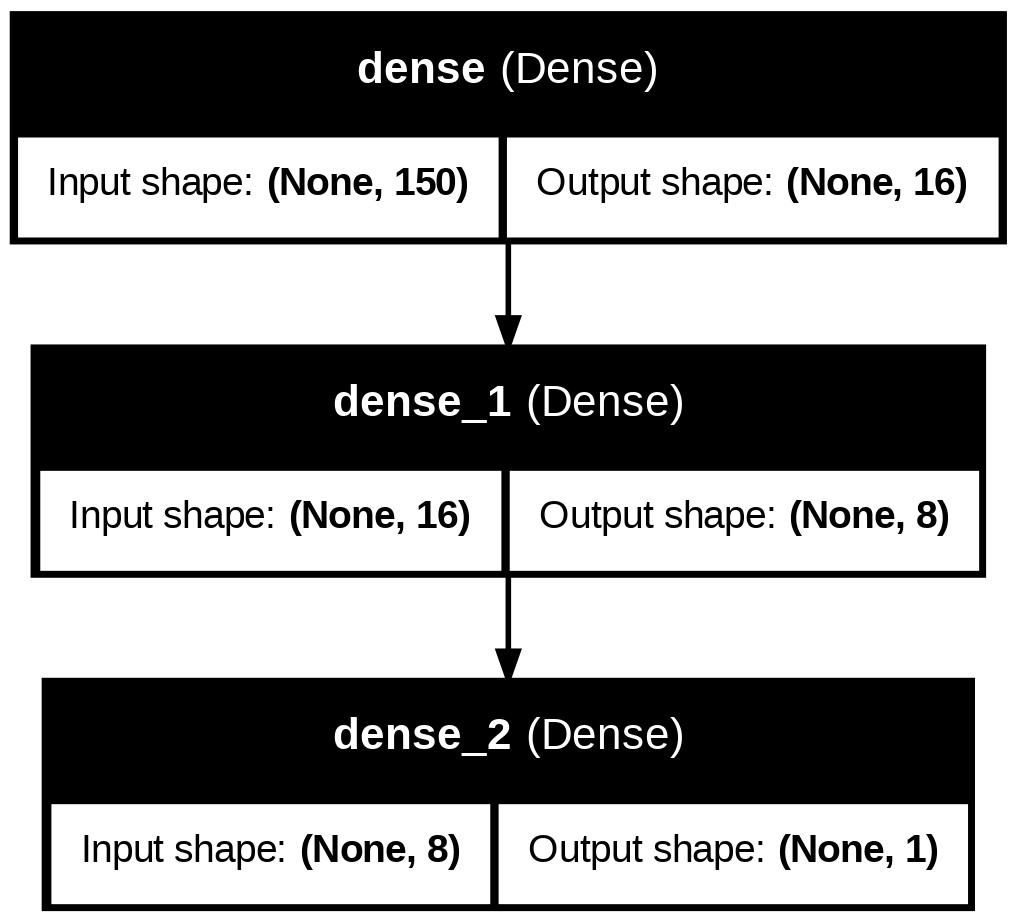

In [ ]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Ensure the model is defined and compiled before plotting
# (It should be from the previous 'ANN Model Summary' cell)

# Generate the model plot and save it to a file
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the saved image in the notebook
Image('model_architecture.png')

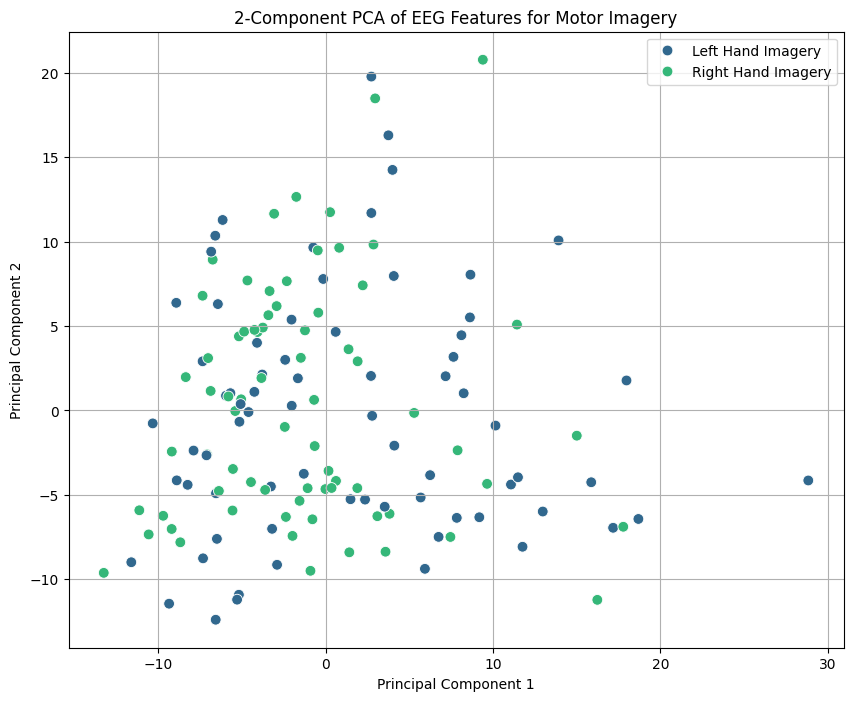

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data = X_pca, columns = ['principal component 1', 'principal component 2'])
pca_df['label'] = y

# Map numerical labels to descriptive strings for better plotting
pca_df['movement_type'] = pca_df['label'].map({0: 'Left Hand Imagery', 1: 'Right Hand Imagery'})

# Plot the principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='movement_type', data=pca_df, s=60, palette='viridis')
plt.title('2-Component PCA of EEG Features for Motor Imagery')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
model.fit(X_train, y_train, epochs=20)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -76.9259 
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -86.9901 
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -97.9535 
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: -109.7947 
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -122.5604 
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -136.2653 
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: -151.0978
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -166.8272 
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -183.6553 
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -201.5887 
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: -

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is available

# Re-extract X and y from the original DataFrame `df`
# This ensures we start with fresh data, undoing any previous incorrect modifications
X = df.drop("Label", axis=1)
y = df["Label"]

# Convert labels: 769 (Motor imagery: left hand) -> 0, 770 (Motor imagery: right hand) -> 1
# Based on the event_id, these correspond to integer IDs 7 and 8 respectively.
y = np.where(y == 7, 0, y) # Map event_id 7 (corresponding to 769) to 0
y = np.where(y == 8, 1, y) # Map event_id 8 (corresponding to 770) to 1

# Keep only 2 classes (0 and 1) after conversion
mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]

In [ ]:
print(f"Shape of X after filtering: {X.shape}")
print(f"Shape of y after filtering: {y.shape}")

Shape of X after filtering: (0, 150)
Shape of y after filtering: (0,)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Ensure numpy
X = np.array(X)
y = np.array(y)

# Flatten if needed
if len(X.shape) > 2:
    X = X.reshape(X.shape[0], -1)

# Convert to numeric safely
X = pd.DataFrame(X)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X = X.values

# Clean NaN / inf
X = np.nan_to_num(X)

# Fix labels (VERY IMPORTANT)
y = np.where(y == 769, 0, y)
y = np.where(y == 770, 1, y)

# Keep only valid classes
mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]

# Final check
print("Final shape:", X.shape)
print("Labels:", set(y))

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Final shape: (144, 150)
Labels: {np.int64(0), np.int64(1)}


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy on X_test: {accuracy*100:.2f}%")

Accuracy on X_test: 62.07%


In [ ]:
!pip install mne

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import mne
import zipfile
import os

# --- Re-define gdf_file_name for robustness ---
# Assuming the zip file was previously uploaded to /content/
zip_files_in_content = [f for f in os.listdir('.') if f.endswith('.zip')]
if zip_files_in_content:
    zip_file_name = zip_files_in_content[0]
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    unzipped_files = os.listdir('.')
    gdf_file_name = [f for f in unzipped_files if f.endswith('.gdf')][0]
    print(f"Successfully extracted GDF file: {gdf_file_name}")
else:
    # Fallback or error if zip file is not found (should not happen if previous cells were run)
    raise FileNotFoundError("BCICIV_2a_gdf.zip not found. Please upload it again.")

# --- Start of full Data Pipeline (Re-execution for robustness) ---
# Step 3: Load and Preprocess Raw EEG Data with MNE (from cell 39cae435)
raw = mne.io.read_raw_gdf(gdf_file_name, preload=True)
raw.filter(7., 30.)  # Motor imagery band

# Step 4: Extract Events and Create Epochs (from cells mfyd8q6hWU3H and hDfHmKvHWZvy)
events, event_id = mne.events_from_annotations(raw)
epochs = mne.Epochs(raw, events, event_id, tmin=0, tmax=2, preload=True, event_repeated='merge', baseline=(0, 0))
data = epochs.get_data() # data shape: (n_epochs, n_channels, n_times)
labels = epochs.events[:, -1] # Extract event IDs as labels

# Step 5: Feature Extraction (from cell d3862c28)
features = []
n_channels = data.shape[1] # Derive n_channels from data

for trial in data: # trial shape: (n_channels, n_times)
    epoch_features = []

    for channel_idx in range(n_channels):
        channel_data = trial[channel_idx, :] # channel_data shape: (n_times,)

        epoch_features.append(np.mean(channel_data))
        epoch_features.append(np.var(channel_data))
        epoch_features.append(np.sqrt(np.mean(channel_data**2)))
        epoch_features.append(np.max(channel_data))
        epoch_features.append(np.min(channel_data))

        fft_channel = np.fft.fft(channel_data)
        freq_feature = np.mean(np.abs(fft_channel))
        epoch_features.append(freq_feature)
    features.append(epoch_features)

n_features_per_channel = 6
feature_names = ["Mean", "Variance", "RMS", "Max", "Min", "Frequency"]
all_column_names = []
for ch_idx in range(n_channels):
    for f_name in feature_names:
        all_column_names.append(f"{f_name}_ch{ch_idx+1}")

df = pd.DataFrame(features, columns=all_column_names)
df["Label"] = labels
# --- End of full Data Pipeline ---

# --- Start of Data Preparation (adapted from cell 28d749e0) ---
X = df.drop("Label", axis=1)
y = df["Label"]

X = np.array(X)
y = np.array(y)

# Convert labels:
# Based on the event_id from MNE, '769' (Motor imagery: left hand) corresponds to label 7,
# and '770' (Motor imagery: right hand) corresponds to label 8.
# We will map these to 0 and 1 respectively for binary classification.
y_mapped = np.where(y == event_id[np.str_('769')], 0, y) # Map '769' to 0
y_mapped = np.where(y_mapped == event_id[np.str_('770')], 1, y_mapped) # Map '770' to 1

mask = (y_mapped == 0) | (y_mapped == 1)
X = X[mask]
y = y_mapped[mask] # Use the mapped labels here

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.05, random_state=42, stratify=y)
# --- End of Data Preparation ---

# Re-define and train the model to ensure it's available in the current execution context
# This code is adapted from cell 'foUGMTPxXxPs'
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model (epochs reduced for quicker execution if re-run)
model.fit(X_train, y_train, epochs=20, verbose=0)

# Make predictions on the test set
y_pred_proba = model.predict(X_test)
# For binary classification, convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2 Score): {r2:.4f}")

Successfully extracted GDF file: A02T.gdf
Extracting GDF parameters from A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 677168  =      0.000 ...  2708.672 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
585 matching events found
Applying baseline correction (m

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Mean Squared Error (MSE): 0.6250
R-squared (R2 Score): -1.5000


In [ ]:
from google.colab import files

print("Please upload the BCICIV_2a_gdf.zip file.")
uploaded = files.upload()

Please upload the BCICIV_2a_gdf.zip file.


Saving BCICIV_2a_gdf.zip to BCICIV_2a_gdf.zip
